In [7]:
import pandas as pd
import matplotlib.pyplot as plt
#read the data
xy = pd.read_csv('XY Data Full.txt', sep = '\t')
prod = pd.read_csv('2-production_history.txt', sep = '\t')
xy

,UID,WELLNAME,ALIAS,XCOORD,YCOORD,BOTTOMX,BOTTOMY,KBELEV,TDEPTH,CDATE,...,Status,Zone,Flow_Station,UID.2,PAY,POROSITY,SW,RFo,RFg,SSMA_TimeStamp
0,ACL1010,ACL 10-10,10-10,456103.49,5797256.280,456103.49,5797256.280,2373.031,3215.223,1993-08-13 00:00:00,...,GAS,VI,NE,ACL1010,NaN,NaN,NaN,NaN,NaN,0x0000000000005ECF
1,BTEL1436,BTEL 14-36,14-36,459156.31,5803984.220,459156.31,5803984.220,2401.575,3359.580,1995-01-28 00:00:00,...,P&A,III,N,BTEL1436,NaN,NaN,NaN,NaN,NaN,0x0000000000005ED0
2,HOGL1132,HOGL 11-32,11-32,465255.40,5789000.000,465255.40,5789000.000,2463.583,3197.178,1980-09-06 00:00:00,...,OIL,III,TB0539,HOGL1132,12.6,0.27,0.14,NaN,0.34,0x0000000000005ED1
3,HOGL1228,HOGL 12-28,12-28,453821.84,5802019.870,453821.84,5802019.870,2364.501,3218.504,2008-03-14 00:00:00,...,GAS,V,N,HOGL1228,NaN,6.00,0.25,0.15,NaN,0x0000000000005ED2
4,HOGL1528,HOGL 15-28,15-28,454442.92,5802794.200,454441.31,5802656.830,2367.782,3280.840,2007-09-20 00:00:00,...,GAS,IVA,N,HOGL1528,NaN,36.60,0.28,0.16,NaN,0x0000000000005ED3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,PVEC_0731,PVEC 7-31,C0/07-31,469836.28,5795565.375,469836.28,5795565.375,2454.724,3313.648,1993-05-23 00:00:00,...,OIL,III,TB0532,PVEC_0731,26.4,0.27,0.15,NaN,0.34,0x0000000000005F23
84,PVEC2_0131,PVEC2 1-31,C2/01-31,468843.80,5795773.275,468843.80,5795773.275,2472.113,3187.664,1989-10-14 00:00:00,...,OIL,III,TB0532,PVEC2_0131,36.8,0.25,0.16,NaN,0.34,0x0000000000005F24
85,PVED_0231,PVED 2-31,D0/02-31,469836.72,5797000.000,469836.72,5797000.000,2447.178,3198.819,1993-05-15 00:00:00,...,OIL,IVA,TB0532,PVED_0231,20.4,0.26,0.17,NaN,0.34,0x0000000000005F25
86,PVED_0731,PVED 7-31,D0/07-31,467840.99,5793200.163,467840.99,5793200.163,2468.176,3193.570,1989-06-09 00:00:00,...,OIL,III,TB0532,PVED_0731,11.8,0.27,0.18,NaN,0.34,0x0000000000005F26


In [4]:
# get to know types of wells.
xy['Status'].value_counts()

Status
OIL     75
GAS      5
WINJ     5
P&A      3
Name: count, dtype: int64

In [34]:
# get to know which wells are gas
# filter the xy data for gas wells
oil_wells = xy[xy['Status'] == 'OIL']
oil_wells
xy[xy['Status'] == 'OIL']
# How to do filters
# 1 - write the table name
# 2 - write the column name, write the filter
wells_gt_3300 = xy[xy['TDEPTH'] > 3300]
wells_gt_3300
# & - and, | - or
wells_gas_3250 = xy[(xy['Status'] == 'GAS') & (xy['TDEPTH'] >= 3250)]
wells_gas_3250

,UID,WELLNAME,ALIAS,XCOORD,YCOORD,BOTTOMX,BOTTOMY,KBELEV,TDEPTH,CDATE,...,Status,Zone,Flow_Station,UID.2,PAY,POROSITY,SW,RFo,RFg,SSMA_TimeStamp
4,HOGL1528,HOGL 15-28,15-28,454442.92,5802794.2,454441.31,5802656.83,2367.782,3280.84,2007-09-20 00:00:00,...,GAS,IVA,N,HOGL1528,NaN,36.6,0.28,0.16,NaN,0x0000000000005ED3


In [52]:
Gwells = oil_wells['UID'].unique()
# get the production data for gas wells only
Gwells
oil_prod = prod[prod['UID'].isin(Gwells)] # isin - is a function similar to == for multiple values
oil_prod

,UID,Date,HOURS,OIL,GAS,WATER,COND,ONPROD
0,HOGL3_0132,1994-11-01 0:00,584,3168.65,670.26,1440.369,0.0,1.0
1,HOGL3_0132,1994-12-01 0:00,744,3830.34,753.81,2270.626,0.0,1.0
2,HOGL3_0132,1995-01-01 0:00,734,4151.12,626.96,2815.954,0.0,1.0
3,HOGL3_0132,1995-02-01 0:00,628,4181.31,676.94,2586.375,0.0,1.0
4,HOGL3_0132,1995-03-01 0:00,732,7018.02,997.67,6918.176,0.0,1.0
...,...,...,...,...,...,...,...,...
21035,HOGL3_0132,1994-06-01 0:00,620,5015.34,1691.65,3331.719,0.0,1.0
21036,HOGL3_0132,1994-07-01 0:00,727,5785.22,2579.95,3767.604,0.0,1.0
21037,HOGL3_0132,1994-08-01 0:00,736,5685.84,2353.40,4085.240,0.0,1.0
21038,HOGL3_0132,1994-09-01 0:00,695,5308.45,1835.87,3971.394,0.0,1.0


In [36]:
#Water Oil Ratio Analysis
# filter down to a single well
# select your well
# make sure to set date properly
a_well = 'HOGL2_0332'
df = oil_prod[oil_prod['UID'] == a_well]
df['WOR'] = df['WATER']/df['OIL']
df['WOR']
df = df.reset_index()
df.index = df.index + 1
df

C:\Users\HP\AppData\Local\Temp\ipykernel_17396\427809811.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['WOR'] = df['WATER']/df['OIL']


,index,UID,Date,HOURS,OIL,GAS,WATER,COND,ONPROD,WOR
1,19259,HOGL2_0332,1992-10-01 0:00,740,4222.358,0.00,42.1418,0.0,1.0,0.009981
2,19260,HOGL2_0332,1992-11-01 0:00,701,4524.898,0.00,879.9461,0.0,1.0,0.194468
3,19261,HOGL2_0332,1992-12-01 0:00,704,11090.050,2309.33,1781.9060,0.0,1.0,0.160676
4,19262,HOGL2_0332,1993-01-01 0:00,700,9157.820,1734.99,4507.2870,0.0,1.0,0.492179
5,19263,HOGL2_0332,1993-02-01 0:00,618,7804.250,1899.33,5425.6010,0.0,1.0,0.695211
...,...,...,...,...,...,...,...,...,...,...
192,19450,HOGL2_0332,2008-09-01 0:00,716,2584.950,1092.41,47215.1800,0.0,1.0,18.265413
193,19451,HOGL2_0332,2008-10-01 0:00,744,2618.920,836.82,48307.7200,0.0,1.0,18.445665
194,19452,HOGL2_0332,2008-11-01 0:00,720,2588.730,496.91,46724.5700,0.0,1.0,18.049225
195,19453,HOGL2_0332,2008-12-01 0:00,734,2525.830,576.76,40726.6000,0.0,1.0,16.124046


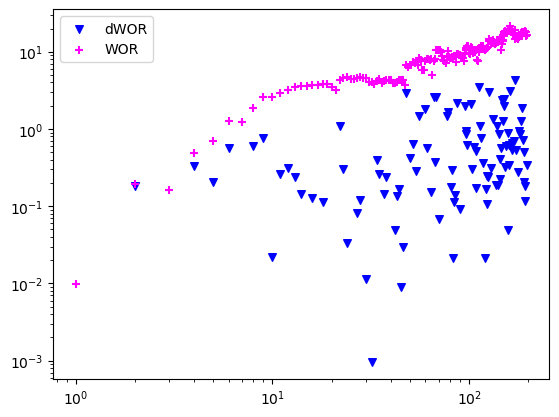

In [47]:
df['DWOR'] = df['WOR'].diff()/df.index.diff() # diff() - difference between current and previous value
plt.scatter(df.index, df['DWOR'], c='blue', s=30, marker='v', label='dWOR')
plt.scatter(df.index, df['WOR'], c='magenta', s=30, marker='+', label='WOR')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.savefig(a_well + '.png')

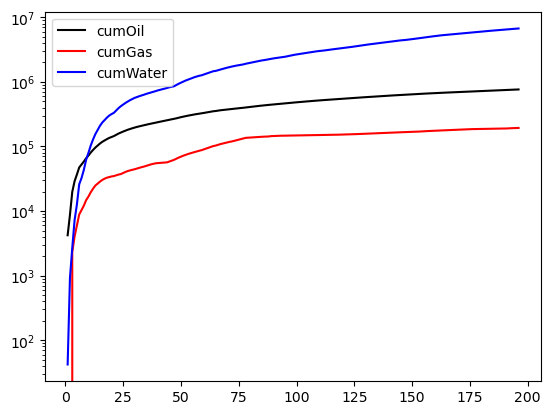

In [51]:
#calculate cummulative production
df['cumOil'] = df['OIL'].cumsum()
df['cumWater'] = df['WATER'].cumsum()
df['cumGas'] = df['GAS'].cumsum()
plt.plot(df.index, df['cumOil'], c='black', label='cumOil')
plt.plot(df.index, df['cumGas'], c='red', label='cumGas')
plt.plot(df.index, df['cumWater'], c='blue', label='cumWater')  
plt.yscale('log')
plt.legend()  
df.to_csv(a_well + '_output.csv')  